In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = ["mpg","cylinders","displacement","horsepower","weight",
           "acceleration","model_year","origin","car_name"]

df = pd.read_csv(url, delim_whitespace=True, names=columns, na_values="?")

df = df.dropna()

C:\Users\dhany\AppData\Local\Temp\ipykernel_4240\1782991564.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, names=columns, na_values="?")


In [3]:
X = df[['weight']].values
y = df['mpg'].values

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [5]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

print("Linear R2:", r2_score(y_test, y_pred_lin))

Linear R2: 0.6533466675646016


In [6]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred_poly = model.predict(X_test_poly)

print("Polynomial R2:", r2_score(y_test, y_pred_poly))

Polynomial R2: 0.6730234425886847


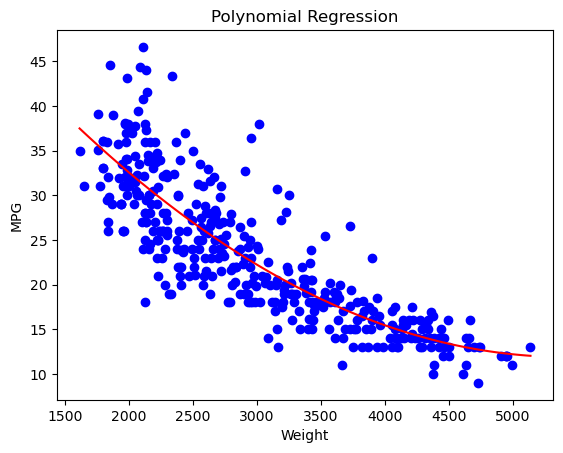

In [7]:
plt.scatter(X, y, color='blue')

X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)

plt.plot(X_grid, model.predict(X_grid_poly), color='red')

plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Polynomial Regression")
plt.show()

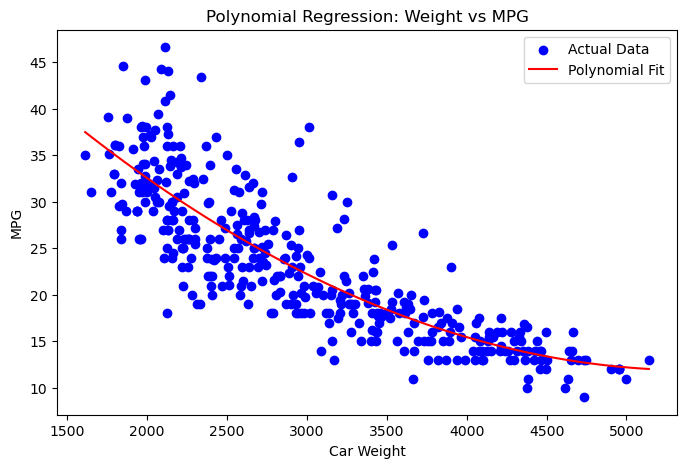

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color='blue', label="Actual Data")

X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)

plt.plot(X_grid, model.predict(X_grid_poly), color='red', label="Polynomial Fit")

plt.xlabel("Car Weight")
plt.ylabel("MPG")
plt.title("Polynomial Regression: Weight vs MPG")
plt.legend()

plt.show()

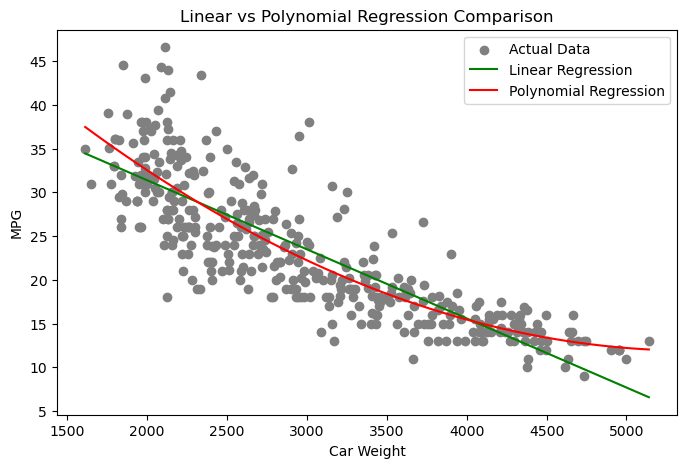

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color='gray', label="Actual Data")

# Linear line
plt.plot(X_grid, lin_model.predict(X_grid), color='green', label="Linear Regression")

# Polynomial curve
plt.plot(X_grid, model.predict(X_grid_poly), color='red', label="Polynomial Regression")

plt.xlabel("Car Weight")
plt.ylabel("MPG")
plt.title("Linear vs Polynomial Regression Comparison")
plt.legend()

plt.show()

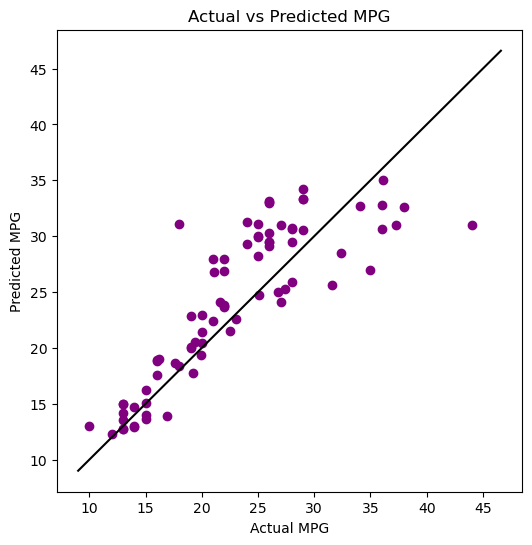

In [10]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_poly, color='purple')

plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black')

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.show()